In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
# 在 Jupyter Notebook 中启用交互式显示
%matplotlib inline

# 设置matplotlib支持中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'Arial Unicode MS']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

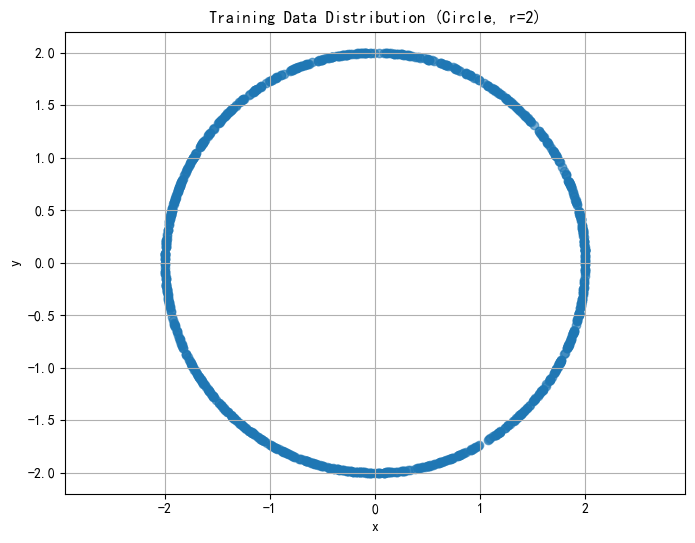

Data range: x=[-2.00, 2.00], y=[-2.00, 2.00]
Average distance to origin: 2.00


In [2]:
def sample_data(n):
    angles = torch.rand(n) * 2 * torch.pi
    r = 2.0
    x = torch.stack([r * torch.cos(angles), r * torch.sin(angles)], dim=1)
    return x

# 分析训练数据的分布
sample_data_points = sample_data(1000)
plt.figure(figsize=(8, 6))
plt.scatter(sample_data_points[:, 0], sample_data_points[:, 1], alpha=0.6)
plt.title('Training Data Distribution (Circle, r=2)')  # 使用英文避免中文乱码
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.grid(True)
plt.show()

print(f"Data range: x=[{sample_data_points[:,0].min():.2f}, {sample_data_points[:,0].max():.2f}], y=[{sample_data_points[:,1].min():.2f}, {sample_data_points[:,1].max():.2f}]")
print(f"Average distance to origin: {torch.norm(sample_data_points, dim=1).mean():.2f}")

In [3]:
class VelocityNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x, t):
        t = t.unsqueeze(-1).repeat(1, 1)
        return self.net(torch.cat([x, t], dim=1))


In [4]:
class NoiseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x, t):
        t = t.unsqueeze(-1)
        return self.net(torch.cat([x, t], dim=1))

In [5]:
net_flow = VelocityNet()
optimizer = torch.optim.Adam(net_flow.parameters(), lr=1e-3)

for step in range(2000):
    x1 = sample_data(256)
    x0 = torch.randn_like(x1)
    t = torch.rand(256)

    xt = (1 - t[:,None])*x0 + t[:,None]*x1
    v_target = x1 - x0

    v_pred = net_flow(xt, t)
    loss = F.mse_loss(v_pred, v_target)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


In [6]:
betas = torch.linspace(1e-4, 0.02, 100)
alphas = 1 - betas
alpha_bar = torch.cumprod(alphas, dim=0)


In [7]:
net_ddim = NoiseNet()
optimizer = torch.optim.Adam(net_ddim.parameters(), lr=1e-3)

for step in range(2000):
    x1 = sample_data(256)

    t = torch.randint(0, 100, (256,))
    a = alpha_bar[t].unsqueeze(1)

    eps = torch.randn_like(x1)
    xt = torch.sqrt(a)*x1 + torch.sqrt(1-a)*eps

    eps_pred = net_ddim(xt, t.float() / 100)
    loss = F.mse_loss(eps_pred, eps)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


Step 0: Loss = 1.1853
Step 500: Loss = 0.6125
Step 1000: Loss = 0.6168
Step 1500: Loss = 0.6289


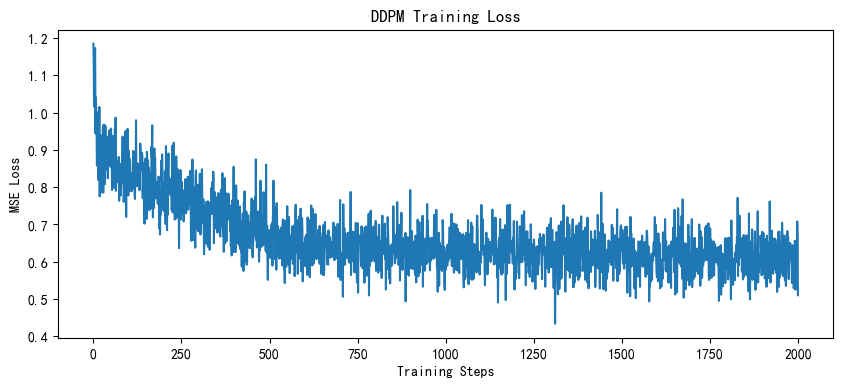

Final loss: 0.5098
Average loss for last 100 steps: 0.6104


In [8]:
# DDPM Network Training (with loss monitoring)
net_ddpm = NoiseNet()
optimizer = torch.optim.Adam(net_ddpm.parameters(), lr=1e-3)

losses = []
for step in range(2000):
    x1 = sample_data(256)

    # Random timestep sampling
    t = torch.randint(0, 100, (256,))
    a = alpha_bar[t].unsqueeze(1)

    # Add noise
    eps = torch.randn_like(x1)
    xt = torch.sqrt(a)*x1 + torch.sqrt(1-a)*eps

    # Predict noise
    eps_pred = net_ddpm(xt, t.float() / 100)
    loss = F.mse_loss(eps_pred, eps)
    losses.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if step % 500 == 0:
        print(f"Step {step}: Loss = {loss.item():.4f}")

# Plot loss curve
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.title('DDPM Training Loss')
plt.xlabel('Training Steps')
plt.ylabel('MSE Loss')
plt.show()

print(f"Final loss: {losses[-1]:.4f}")
print(f"Average loss for last 100 steps: {np.mean(losses[-100:]):.4f}")

In [9]:
def sample_flow_trajectory():
    x = torch.randn(200, 2)
    traj = [x.detach().numpy()]
    steps = 30
    times = torch.linspace(0, 1, steps)

    for i in range(steps-1):
        t = times[i].expand(200)
        v = net_flow(x, t)
        x = x + (1/steps)*v
        traj.append(x.detach().numpy())
    return traj

traj_flow = sample_flow_trajectory()


In [10]:
# 保存Flow Matching动图为GIF文件
fig, ax = plt.subplots()
sc = ax.scatter([], [])
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_title("Flow Matching Trajectory")

def update(i):
    sc.set_offsets(traj_flow[i])
    return sc,

# 创建动画
ani = FuncAnimation(fig, update, frames=len(traj_flow), interval=100)

# 保存为GIF文件
output_path = "../../others/flow_matching_trajectory.gif"
ani.save(output_path, writer='pillow', fps=10)
print(f"Flow Matching动图已保存到: {output_path}")

# 在 Jupyter Notebook 中显示动画
display(HTML(ani.to_jshtml()))

plt.close()  # 关闭静态图像, 避免重复显示

Flow Matching动图已保存到: ../../others/flow_matching_trajectory.gif


In [11]:
def sample_ddim_trajectory():
    x = torch.randn(200, 2)
    traj = [x.detach().numpy()]

    for i in reversed(range(1, 100)):
        t = torch.full((200,), float(i) / 100)
        eps = net_ddim(x, t)

        a = alpha_bar[i]
        a_prev = alpha_bar[i-1]

        x0_pred = (x - torch.sqrt(1-a)*eps) / torch.sqrt(a)
        x = torch.sqrt(a_prev)*x0_pred
        traj.append(x.detach().numpy())

    return traj

traj_ddim = sample_ddim_trajectory()


In [12]:
# 保存DDIM动图为GIF文件
fig, ax = plt.subplots()
sc = ax.scatter([], [])
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_title("DDIM Trajectory")

def update(i):
    sc.set_offsets(traj_ddim[i])
    return sc,

# 创建动画
ani = FuncAnimation(fig, update, frames=len(traj_ddim), interval=100)

# 保存为GIF文件
output_path = "../../others/ddim_trajectory.gif"
ani.save(output_path, writer='pillow', fps=10)
print(f"DDIM动图已保存到: {output_path}")

# 在 Jupyter Notebook 中显示动画
display(HTML(ani.to_jshtml()))

plt.close()  # 关闭静态图像, 避免重复显示

DDIM动图已保存到: ../../others/ddim_trajectory.gif


DDPM动图已保存到: ../../others/ddpm_trajectory.gif


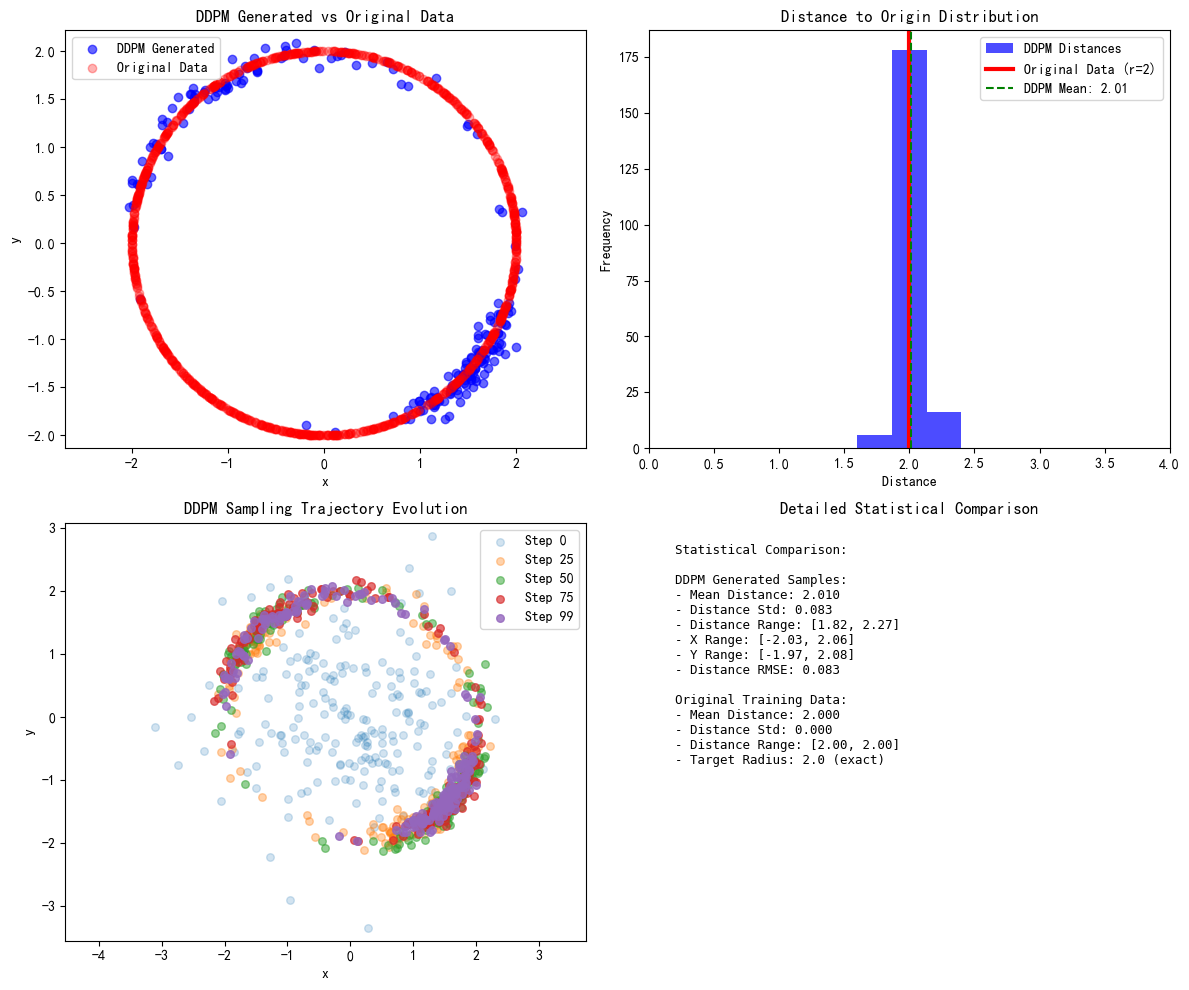

DDPM Model Computational Result Analysis:
1. Data Fit: Can DDPM learn circular distribution?
   - Mean distance: 2.010 (target: 2.0)
   - Distance error: 0.083
2. Noise Level: Distance std deviation = 0.083
3. Distribution Match: ✓ Good
4. Randomness: Results vary with each run


In [13]:
def sample_ddpm_trajectory():
    x = torch.randn(200, 2)
    traj = [x.detach().numpy()]

    # DDPM reverse diffusion process (from t=T to t=0)
    for i in reversed(range(1, 100)):
        t = torch.full((200,), float(i) / 100)
        
        # Predict noise
        eps = net_ddpm(x, t)
        
        # Calculate DDPM coefficients
        a = alpha_bar[i]
        a_prev = alpha_bar[i-1]
        beta = 1 - a/a_prev
        
        # Calculate mean
        eps_coef = (1 - a_prev) / torch.sqrt(1 - a)
        mean = (1 / torch.sqrt(a)) * (x - eps_coef * eps)
        
        # Add noise (except for the last step)
        if i > 1:
            x = mean + torch.sqrt(beta) * torch.randn_like(x)
        else:
            x = mean
            
        traj.append(x.detach().numpy())

    return traj

traj_ddpm = sample_ddpm_trajectory()

# 保存DDPM动图为GIF文件
fig, ax = plt.subplots()
sc = ax.scatter([], [])
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_title("DDPM Trajectory")

def update(i):
    sc.set_offsets(traj_ddpm[i])
    return sc,

# Create animation
ani = FuncAnimation(fig, update, frames=len(traj_ddpm), interval=100)

# 保存为GIF文件
output_path = "../../others/ddpm_trajectory.gif"
ani.save(output_path, writer='pillow', fps=10)
print(f"DDPM动图已保存到: {output_path}")

# Display animation in Jupyter Notebook
display(HTML(ani.to_jshtml()))

plt.close()  # Close static image to avoid duplicate display

# Analyze DDPM final results
final_samples = torch.tensor(traj_ddpm[-1])

# Create analysis charts
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Final sample distribution
axes[0,0].scatter(final_samples[:, 0], final_samples[:, 1], alpha=0.6, c='blue', label='DDPM Generated')
axes[0,0].scatter(sample_data_points[:, 0], sample_data_points[:, 1], alpha=0.3, c='red', label='Original Data')
axes[0,0].set_title('DDPM Generated vs Original Data')
axes[0,0].set_xlabel('x')
axes[0,0].set_ylabel('y')
axes[0,0].legend()
axes[0,0].axis('equal')

# 2. Distance distribution analysis (fixed bins issue)
distances_generated = torch.norm(final_samples, dim=1)
distances_original = torch.norm(sample_data_points, dim=1)

# Create appropriate histogram for DDPM samples
axes[0,1].hist(distances_generated.numpy(), bins=15, alpha=0.7, label='DDPM Distances', color='blue', range=(0, 4))
# Add vertical line for original data since it's all 2.0
axes[0,1].axvline(x=2.0, color='red', linewidth=3, label='Original Data (r=2)')
axes[0,1].axvline(x=distances_generated.mean(), color='green', linestyle='--', label=f'DDPM Mean: {distances_generated.mean():.2f}')
axes[0,1].set_title('Distance to Origin Distribution')
axes[0,1].set_xlabel('Distance')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_xlim(0, 4)
axes[0,1].legend()

# 3. Trajectory evolution process
traj_array = np.array(traj_ddpm)
selected_steps = [0, 25, 50, 75, 99]  # Select key moments

for idx, step in enumerate(selected_steps):
    alpha = 0.2 + idx * 0.15
    axes[1,0].scatter(traj_array[step, :, 0], traj_array[step, :, 1], 
                     alpha=alpha, s=30, label=f'Step {step}')

axes[1,0].set_title('DDPM Sampling Trajectory Evolution')
axes[1,0].set_xlabel('x')
axes[1,0].set_ylabel('y')
axes[1,0].legend()
axes[1,0].axis('equal')

# 4. Statistical comparison
error_rate = torch.mean((distances_generated - 2.0)**2).sqrt()  # RMSE of distance error

stats_text = f"""Statistical Comparison:

DDPM Generated Samples:
- Mean Distance: {distances_generated.mean():.3f}
- Distance Std: {distances_generated.std():.3f}
- Distance Range: [{distances_generated.min():.2f}, {distances_generated.max():.2f}]
- X Range: [{final_samples[:, 0].min():.2f}, {final_samples[:, 0].max():.2f}]
- Y Range: [{final_samples[:, 1].min():.2f}, {final_samples[:, 1].max():.2f}]
- Distance RMSE: {error_rate:.3f}

Original Training Data:
- Mean Distance: {distances_original.mean():.3f}
- Distance Std: {distances_original.std():.3f}
- Distance Range: [{distances_original.min():.2f}, {distances_original.max():.2f}]
- Target Radius: 2.0 (exact)
"""

axes[1,1].text(0.05, 0.95, stats_text, transform=axes[1,1].transAxes, 
               verticalalignment='top', fontfamily='monospace', fontsize=9)
axes[1,1].set_title('Detailed Statistical Comparison')
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

print("DDPM Model Computational Result Analysis:")
print("="*50)
print(f"1. Data Fit: Can DDPM learn circular distribution?")
print(f"   - Mean distance: {distances_generated.mean():.3f} (target: 2.0)")
print(f"   - Distance error: {error_rate:.3f}")
print(f"2. Noise Level: Distance std deviation = {distances_generated.std():.3f}")
print(f"3. Distribution Match: {'✓ Good' if error_rate < 0.3 else '✗ Poor'}")
print(f"4. Randomness: Results vary with each run")